# Change samping frequency
Sometimes we require resample survey data at either a heigher or lower sampling frequency. Here we show how to do both.

In [1]:
# %load_ext autoreload
# %autoreload 2

import cmocean
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import verde as vd

import airbornegeo

/home/sungw937/airbornegeo/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_df = pd.read_csv("data/AGAP_gravity_survey_processed.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "line",
        "unixtime",
        "distance_along_line",
        "grav_disturbance_filt",
    ]
][::5]  # every 5th point
data_df.head()

,easting,northing,line,unixtime,distance_along_line,grav_disturbance_filt
0,1.000024e+06,226237.330771,1,1.229507e+09,0.000000,49.38
5,1.000319e+06,226283.309168,1,1.229507e+09,299.027209,49.71
10,1.000613e+06,226327.808992,1,1.229507e+09,595.833891,50.01
15,1.000903e+06,226371.179740,1,1.229507e+09,888.955840,50.27
20,1.001192e+06,226414.710863,1,1.229507e+09,1181.733769,50.52


## Reduce sampling frequency
For this we will use block-reduction, where we define spatial windows (1D), or blocks (2D), and for all data within the block, retain only the mean or median values.

In [3]:
# extract a single line from the survey
line_df = data_df[data_df.line == 8]
line_df

,easting,northing,line,unixtime,distance_along_line,grav_disturbance_filt
21815,1.064934e+06,327364.065720,8,1.230574e+09,202.954030,56.97
21820,1.065268e+06,327411.697676,8,1.230574e+09,540.476913,55.86
21825,1.065601e+06,327464.248325,8,1.230574e+09,878.033672,54.83
21830,1.065934e+06,327524.876461,8,1.230574e+09,1216.298627,53.83
21835,1.066267e+06,327589.259632,8,1.230574e+09,1555.357945,52.86
...,...,...,...,...,...,...
25255,1.321821e+06,373028.825792,8,1.230578e+09,261161.216753,-0.68
25260,1.322151e+06,373081.094428,8,1.230578e+09,261495.865268,-0.63
25265,1.322480e+06,373141.185876,8,1.230578e+09,261829.523736,-0.47
25270,1.322807e+06,373203.581372,8,1.230578e+09,262162.742950,-0.22


### Block-reduce by distance
By setting `reduce_by` to 'distance_along_line' and `spacing` to 2000, we can block reduce the data to have 1 point every 2000 meters.

In [4]:
blocked_line = airbornegeo.block_reduce(
    line_df,
    np.median,
    spacing=2000,
    reduce_by="distance_along_line",
)
blocked_line

,distance_along_line,easting,northing,line,unixtime,grav_disturbance_filt
0,1047.166150,1.065768e+06,327494.562393,8.0,1.230574e+09,54.330
1,3090.706931,1.067777e+06,327868.671771,8.0,1.230575e+09,49.095
2,5121.188200,1.069772e+06,328242.618483,8.0,1.230575e+09,47.350
3,7161.536703,1.071772e+06,328645.464282,8.0,1.230575e+09,47.825
4,9206.329651,1.073790e+06,328976.197080,8.0,1.230575e+09,48.940
...,...,...,...,...,...,...
112,253340.621952,1.314120e+06,371682.595111,8.0,1.230578e+09,-2.910
113,255348.383383,1.316093e+06,372053.647164,8.0,1.230578e+09,-0.215
114,257337.687975,1.318042e+06,372450.672575,8.0,1.230578e+09,-0.105
115,259494.763940,1.320169e+06,372809.857086,8.0,1.230578e+09,-0.080


Text(0, 0.5, 'Gravity disturbance (mGal)')

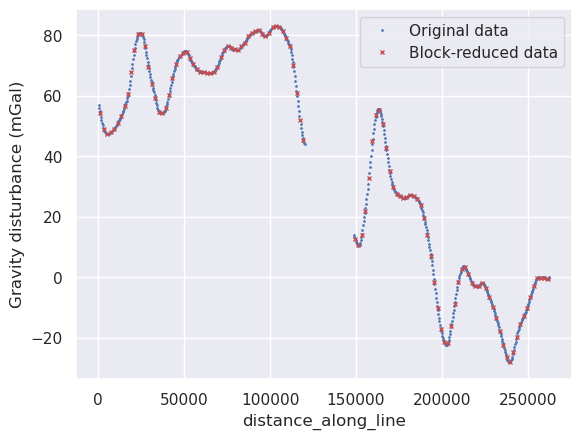

In [5]:
ax = line_df.plot.line(
    "distance_along_line",
    "grav_disturbance_filt",
    style="bp",
    ms=1,
    label="Original data",
)
ax = blocked_line.plot.line(
    "distance_along_line",
    "grav_disturbance_filt",
    style="rx",
    ms=3,
    ax=ax,
    label="Block-reduced data",
)
ax.set_ylabel("Gravity disturbance (mGal)")

### Block-reduce by time
By setting `reduce_by` to 'unixtime' and `spacing` to 60, we can block reduce the data to have 1 point every minute along the flight.

In [6]:
blocked_line = airbornegeo.block_reduce(
    line_df,
    np.median,
    spacing=60,
    reduce_by="unixtime",
)
blocked_line

,unixtime,easting,northing,line,distance_along_line,grav_disturbance_filt
0,1.230575e+09,1.066938e+06,327715.929722,8.0,2238.340303,51.000
1,1.230575e+09,1.071104e+06,328504.882220,8.0,6478.392083,47.520
2,1.230575e+09,1.075127e+06,329234.502637,8.0,10568.251984,50.170
3,1.230575e+09,1.079154e+06,329908.814386,8.0,14652.187462,55.325
4,1.230575e+09,1.083161e+06,330641.426426,8.0,18725.126925,65.610
5,1.230575e+09,1.087190e+06,331337.323567,8.0,22814.338307,79.745
6,1.230575e+09,1.091191e+06,332033.787693,8.0,26875.778337,77.205
7,1.230575e+09,1.095183e+06,332703.209265,8.0,30924.850905,64.805
8,1.230575e+09,1.099178e+06,333472.214395,8.0,34993.496976,55.010
9,1.230575e+09,1.103235e+06,334123.659321,8.0,39103.107669,55.590


Text(0, 0.5, 'Gravity disturbance (mGal)')

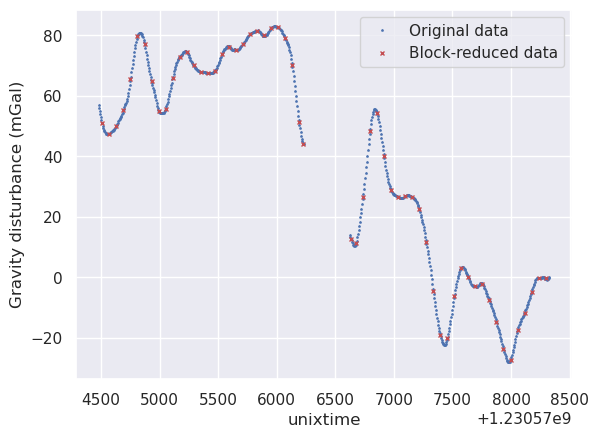

In [7]:
ax = line_df.plot.line(
    "unixtime", "grav_disturbance_filt", style="bp", ms=1, label="Original data"
)
ax = blocked_line.plot.line(
    "unixtime",
    "grav_disturbance_filt",
    style="rx",
    ms=3,
    ax=ax,
    label="Block-reduced data",
)
ax.set_ylabel("Gravity disturbance (mGal)")

## Block-reduce all lines in a survey

By supplying 'line' to the `groupby_column`, the block-reduce occurs only on 1 line at a time. This means for lines that are closer together than the spacing, or where lines cross, the values from other lines within the same block are not included in the block-reduction.

In [8]:
blocked_survey = airbornegeo.block_reduce(
    data_df,
    np.median,
    spacing=5000,
    reduce_by="distance_along_line",
    groupby_column="line",
)
blocked_survey

Segments: 100%|██████████| 100/100 [00:03<00:00, 25.16it/s]


,distance_along_line,easting,northing,unixtime,grav_disturbance_filt,line
0,2384.024088,1.002378e+06,226611.524394,1.229507e+09,51.06,1
1,7455.801489,1.007376e+06,227469.843549,1.229507e+09,54.27,1
2,12553.598397,1.012393e+06,228353.271366,1.229507e+09,60.07,1
3,17554.808264,1.017305e+06,229272.573119,1.229507e+09,66.20,1
4,22537.902177,1.022217e+06,230102.183617,1.229507e+09,79.94,1
...,...,...,...,...,...,...
4336,56739.972830,1.584069e+06,518323.937228,1.230381e+09,-5.63,100
4337,61640.015776,1.584931e+06,513501.388032,1.230381e+09,-0.32,100
4338,66624.305342,1.585845e+06,508603.610165,1.230382e+09,-1.19,100
4339,71654.861120,1.586682e+06,503644.752003,1.230382e+09,-7.01,100


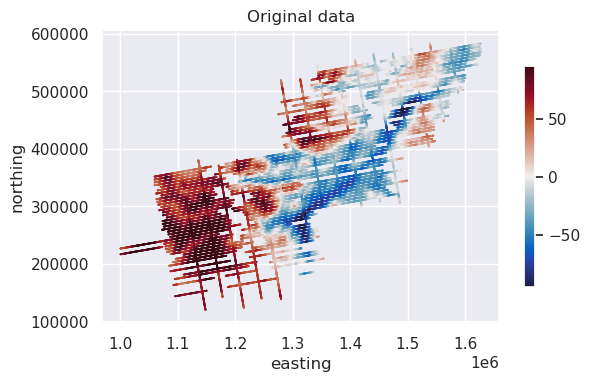

In [9]:
max_abs = vd.maxabs(data_df.grav_disturbance_filt, percentile=95)

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filt",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Original data",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.6)
plt.show()

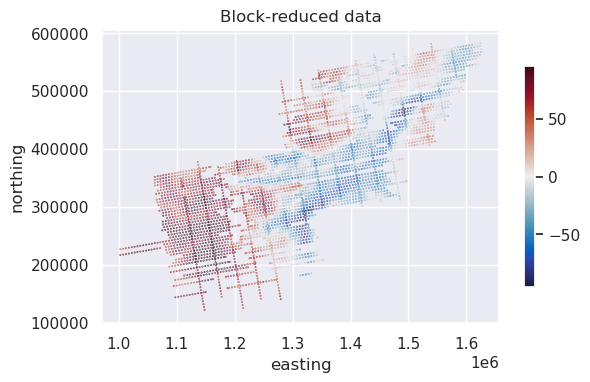

In [10]:
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filt",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Block-reduced data",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.6)
plt.show()

## Increase or change sampling frequency
Below we show how to increase the sampling frequency, or resample the data at a specified frequency. This can be done based on any column, but typically you would resample based on a distance along line column, or a time column.

As we can see below, the line data has a value every ~25 seconds.

In [11]:
# extract a single line from the survey
line_df = data_df[data_df.line == 8]
# for demonstration, only retain every 5th point
line_df = line_df[::5]

line_df.head()

,easting,northing,line,unixtime,distance_along_line,grav_disturbance_filt
21815,1.064934e+06,327364.065720,8,1.230574e+09,202.954030,56.97
21840,1.066602e+06,327650.536827,8,1.230575e+09,1895.906697,51.91
21865,1.068273e+06,327963.921140,8,1.230575e+09,3596.305820,48.32
21890,1.069939e+06,328274.457926,8,1.230575e+09,5291.379412,47.31
21915,1.071605e+06,328613.652292,8,1.230575e+09,6991.055147,47.73


In [12]:
resampled_line = airbornegeo.resample(
    line_df,
    spacing=1,
    resample_by="unixtime",
    maxdist=10,  # only retain data within 10 seconds of original data
)
resampled_line

,easting,northing,line,unixtime,distance_along_line,grav_disturbance_filt
0,1.064934e+06,327364.065720,8,1.230574e+09,202.954030,56.970000
1,1.065000e+06,327374.278903,8,1.230574e+09,270.282928,56.760883
2,1.065067e+06,327384.624404,8,1.230574e+09,337.653892,56.551485
3,1.065133e+06,327395.098503,8,1.230574e+09,405.065665,56.341914
4,1.065200e+06,327405.697482,8,1.230574e+09,472.516991,56.132282
...,...,...,...,...,...,...
2894,1.322214e+06,373102.209570,8,1.230578e+09,261561.264904,-0.514936
2895,1.322281e+06,373111.889622,8,1.230578e+09,261628.289612,-0.506920
2896,1.322347e+06,373121.610518,8,1.230578e+09,261695.340734,-0.496811
2897,1.322413e+06,373131.375016,7,1.230578e+09,261762.418649,-0.484531


Text(0, 0.5, 'Gravity disturbance (mGal)')

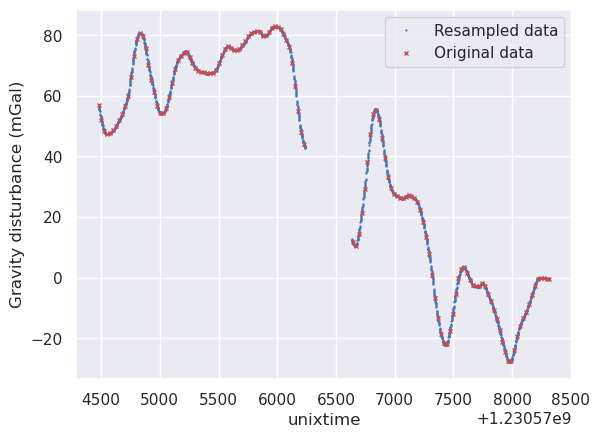

In [13]:
ax = resampled_line.plot.line(
    "unixtime", "grav_disturbance_filt", style="bp", ms=0.6, label="Resampled data"
)
ax = line_df.plot.line(
    "unixtime", "grav_disturbance_filt", style="rx", ms=3, ax=ax, label="Original data"
)
ax.set_ylabel("Gravity disturbance (mGal)")

### Resample all lines in a survey

In [14]:
# for demonstration, only retain every 20th point
data_df = data_df[::20]
data_df

,easting,northing,line,unixtime,distance_along_line,grav_disturbance_filt
0,1.000024e+06,226237.330771,1,1.229507e+09,0.000000,49.38
100,1.005893e+06,227198.570832,1,1.229507e+09,5947.995975,52.61
200,1.011809e+06,228276.845873,1,1.229507e+09,11964.181140,59.36
300,1.017593e+06,229333.885338,1,1.229507e+09,17849.297147,66.73
400,1.023377e+06,230253.701428,1,1.229507e+09,23706.831130,84.16
...,...,...,...,...,...,...
333500,1.583475e+06,521644.499480,100,1.230381e+09,53366.133717,-16.62
333600,1.584374e+06,516551.941983,100,1.230381e+09,58538.402864,-2.12
333700,1.585310e+06,511454.712291,100,1.230381e+09,63721.813255,-0.39
333800,1.586227e+06,506268.485621,100,1.230382e+09,68991.129548,-2.40


In [15]:
resampled_survey = airbornegeo.resample(
    data_df,
    spacing=1,
    resample_by="unixtime",
    maxdist=60,  # only retain data within 60 seconds of original data
    groupby_column="line",
)
resampled_survey

Segments: 100%|██████████| 100/100 [00:00<00:00, 119.54it/s]


,easting,northing,line,unixtime,distance_along_line,grav_disturbance_filt
0,1.000024e+06,226237.330771,1,1.229507e+09,0.000000,49.380000
1,1.000081e+06,226246.043556,1,1.229507e+09,58.214919,49.369844
2,1.000139e+06,226254.777702,1,1.229507e+09,116.464621,49.360794
3,1.000197e+06,226263.533111,1,1.229507e+09,174.748826,49.352843
4,1.000254e+06,226272.309685,1,1.229507e+09,233.067249,49.345984
...,...,...,...,...,...,...
325508,1.587135e+06,501265.625596,100,1.230382e+09,74076.801591,-12.538461
325509,1.587144e+06,501213.721966,100,1.230382e+09,74129.622150,-12.718538
325510,1.587154e+06,501161.826077,100,1.230382e+09,74182.436484,-12.900480
325511,1.587164e+06,501109.938035,100,1.230382e+09,74235.244499,-13.084297


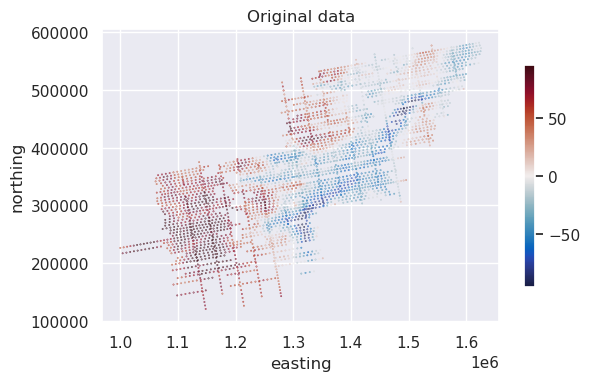

In [16]:
max_abs = vd.maxabs(data_df.grav_disturbance_filt, percentile=95)

ax = data_df.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filt",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Original data",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.6)
plt.show()

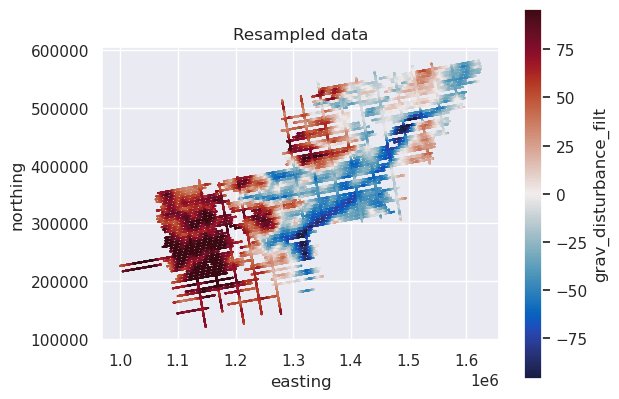

In [19]:
ax = resampled_survey.plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filt",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    title="Resampled data",
)
ax.set_aspect("equal")
plt.show()